In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import statsmodels.api as sm
import seaborn as sns
import bambi as bmb
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
pa_gs = pd.read_csv('data/pa_data.csv')
temps = pd.read_csv("data/pa_temps_supplement.csv")
pa_gs = pa_gs.merge(temps, on=["station_id", "year"], how="left")

pa_gs = pa_gs[pa_gs['year'] >= 1960]
pa_gs = pa_gs.drop(['station_id', 'last_spring_frost_date', 'first_fall_frost_date', 'station_name','state'], axis=1)

In [2]:
def bayesian_model_standardized(data, target_var_name, cov_names):

    sc = StandardScaler()
    data_standardized = sc.fit_transform(data)
    data_standardized = pd.DataFrame(data_standardized)
    data_standardized.columns = data.columns

    std = data.std()
    
    formula = bmb.Formula(f"{target_var_name} ~ {cov_names} + year",
                      f"sigma ~ {cov_names} + year")
    model = bmb.Model(formula, data=data_standardized, dropna = True)
    output = model.fit(idata_kwargs={'log_likelihood':True})

    resid = pa_gs['growing_season_length'] - model.predict(output, inplace=False).posterior["mu"].mean().values

    model_r2_score = model.r2_score(output)
    
    return model, output, std, resid, model_r2_score

In [3]:
cov_set_1 = 'dtr_annual + tmean_spring + tmean_fall'
cov_set_2 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude'
cov_set_3 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual'
cov_set_4 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual'
cov_set_5 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual + pna_annual + amo_annual'
cov_set_6 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual + pna_annual + amo_annual + sst_north_atlantic'
cov_set_7 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual + pna_annual + amo_annual + sst_north_atlantic + pwat_station + dewpoint_station'
cov_set_8 = 'dtr_annual + tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual + pna_annual + amo_annual + sst_north_atlantic + pwat_station + dewpoint_station + soil_moisture_station + cloud_cover_station + evaporation_station'
cov_set_9 = 'dtr_annual + tmean_fall + latitude + longitude + tmax_annual + pna_annual + amo_annual + sst_north_atlantic + pwat_station + soil_moisture_station + cloud_cover_station + evaporation_station'
cov_set_10 = 'dtr_annual + tmean_fall + tmax_annual + amo_annual + sst_north_atlantic + pwat_station + soil_moisture_station + cloud_cover_station + evaporation_station'
cov_set_11 = 'dtr_annual + cloud_cover_station'

In [4]:
cov_set_1_model, cov_set_1_output, cov_set_1_std, cov_set_1_resid, set_1_r2 = bayesian_model_standardized(pa_gs, 'growing_season_length', cov_set_1)
cov_set_2_model, cov_set_2_output, cov_set_2_std, cov_set_2_resid, set_2_r2 = bayesian_model_standardized(pa_gs, 'growing_season_length', cov_set_2)
cov_set_3_model, cov_set_3_output, cov_set_3_std, cov_set_3_resid, set_3_r2 = bayesian_model_standardized(pa_gs, 'growing_season_length', cov_set_3)
cov_set_4_model, cov_set_4_output, cov_set_4_std, cov_set_4_resid, set_4_r2 = bayesian_model_standardized(pa_gs, 'growing_season_length', cov_set_4)
cov_set_5_model, cov_set_5_output, cov_set_5_std, cov_set_5_resid, set_5_r2 = bayesian_model_standardized(pa_gs, 'growing_season_length', cov_set_5)
cov_set_6_model, cov_set_6_output, cov_set_6_std, cov_set_6_resid, set_6_r2 = bayesian_model_standardized(pa_gs, 'growing_season_length', cov_set_6)
cov_set_7_model, cov_set_7_output, cov_set_7_std, cov_set_7_resid, set_7_r2 = bayesian_model_standardized(pa_gs, 'growing_season_length', cov_set_7)
cov_set_8_model, cov_set_8_output, cov_set_8_std, cov_set_8_resid, set_8_r2 = bayesian_model_standardized(pa_gs, 'growing_season_length', cov_set_8)


                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.139       31          228.60 draws/s       0:00:08    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.157       31          232.39 draws/s       0:00:08    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.145       31          220.06 draws/s       0:00:09    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.196       31          227.77 draws/s       0:00:08    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


In [6]:
print(f'Covariate Set 1 R Squared Score (3 covariates): {set_1_r2}')
print(f'Covariate Set 2 R Squared Score (5 covariates): {set_2_r2}')
print(f'Covariate Set 3 R Squared Score (6 covariates): {set_3_r2}')
print(f'Covariate Set 4 R Squared Score (8 covariates): {set_4_r2}')
print(f'Covariate Set 5 R Squared Score (10 covariates): {set_5_r2}')
print(f'Covariate Set 6 R Squared Score (11 covariates): {set_6_r2}')
print(f'Covariate Set 7 R Squared Score (13 covariates): {set_7_r2}')
print(f'Covariate Set 8 R Squared Score (16 covariates): {set_8_r2}')

Covariate Set 1 R Squared Score (3 covariates): residual_R2(mean=0.66, eti_lb=0.65, eti_ub=0.67)
Covariate Set 2 R Squared Score (5 covariates): residual_R2(mean=0.67, eti_lb=0.66, eti_ub=0.67)
Covariate Set 3 R Squared Score (6 covariates): residual_R2(mean=0.67, eti_lb=0.67, eti_ub=0.68)
Covariate Set 4 R Squared Score (8 covariates): residual_R2(mean=0.67, eti_lb=0.67, eti_ub=0.68)
Covariate Set 5 R Squared Score (10 covariates): residual_R2(mean=0.67, eti_lb=0.67, eti_ub=0.68)
Covariate Set 6 R Squared Score (11 covariates): residual_R2(mean=0.67, eti_lb=0.67, eti_ub=0.68)
Covariate Set 7 R Squared Score (13 covariates): residual_R2(mean=0.68, eti_lb=0.67, eti_ub=0.68)
Covariate Set 8 R Squared Score (16 covariates): residual_R2(mean=0.68, eti_lb=0.67, eti_ub=0.68)


In [5]:
az.compare({"model1": cov_set_1_output, "model2": cov_set_2_output, 
            "model3": cov_set_3_output, "model4": cov_set_4_output})

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
model4,0,0.0,0.0,NaN,,,28.3,-5400.0,78.0,0.83
model3,1,-20.0,7.8,0.99,,,22.4,-5400.0,78.0,0.03
model2,2,-50.0,12.0,1.00,,,19.0,-5400.0,77.0,0.07
model1,3,-130.0,19.0,1.00,,,14.3,-5500.0,77.0,0.07


In [6]:
az.compare({"model5": cov_set_5_output, "model6": cov_set_6_output, 
            "model7": cov_set_7_output, "model8": cov_set_8_output})

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
model8,0,0.0,0.0,NaN,,,49.4,-5200.0,77.0,0.79
model7,1,-20.0,8.6,0.99,,,41.1,-5200.0,76.0,0.05
model5,2,-50.0,12.0,1.00,,,33.6,-5300.0,76.0,0.15
model6,3,-50.0,12.0,1.00,,,35.9,-5300.0,76.0,0.00


In [16]:
az.summary(cov_set_1_output).head(10)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.0013,0.0073,-0.01,0.013,7676,3216,1.00,8.3e-05,6e-05
dtr_annual,-0.3533,0.0078,-0.37,-0.34,6157,3343,1.00,0.0001,6.7e-05
tmean_spring,0.232,0.0104,0.21,0.25,4300,3312,1.00,0.00016,0.00011
tmean_fall,0.4322,0.0107,0.41,0.45,4193,3293,1.00,0.00017,0.00012
year,0.072,0.0076,0.06,0.084,5483,3132,1.00,0.0001,7.2e-05
sigma_Intercept,-0.5578,0.0089,-0.57,-0.54,7110,2598,1.00,0.00011,7.5e-05
sigma_dtr_annual,0.0441,0.0089,0.03,0.059,5919,3315,1.00,0.00012,8.1e-05
sigma_tmean_spring,-0.0463,0.0123,-0.066,-0.027,4491,3383,1.00,0.00018,0.00013
sigma_tmean_fall,0.0014,0.0122,-0.018,0.021,4414,3318,1.00,0.00018,0.00013
sigma_year,-0.0894,0.0095,-0.1,-0.075,5432,2925,1.00,0.00013,9e-05


In [17]:
az.summary(cov_set_2_output).head(15)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.0014,0.0072,-0.0098,0.013,7167,3229,1.00,8.5e-05,6.1e-05
dtr_annual,-0.3524,0.0078,-0.36,-0.34,6004,3459,1.00,0.0001,7.2e-05
tmean_spring,0.1954,0.0112,0.18,0.21,4300,3335,1.00,0.00017,0.00012
tmean_fall,0.4033,0.0111,0.39,0.42,4391,3123,1.00,0.00017,0.00012
latitude,-0.0543,0.0096,-0.07,-0.039,4233,3332,1.00,0.00015,0.0001
longitude,0.0831,0.0074,0.071,0.095,7581,3245,1.00,8.4e-05,5.9e-05
year,0.0849,0.0074,0.073,0.097,5943,3068,1.00,9.7e-05,6.9e-05
sigma_Intercept,-0.5712,0.0085,-0.59,-0.56,5837,3325,1.00,0.00011,8.1e-05
sigma_dtr_annual,0.0485,0.0088,0.034,0.063,5601,3418,1.00,0.00012,8.2e-05
sigma_tmean_spring,-0.0431,0.0136,-0.065,-0.022,4021,2838,1.00,0.00021,0.00015


In [18]:
az.summary(cov_set_3_output).head(20)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.0013,0.0073,-0.01,0.013,7472,2833,1.00,8.5e-05,5.8e-05
dtr_annual,-0.4194,0.0115,-0.44,-0.4,2370,2548,1.00,0.00024,0.00017
tmean_spring,0.1172,0.0151,0.093,0.14,3499,2904,1.00,0.00026,0.00019
tmean_fall,0.3172,0.0152,0.29,0.34,2902,2779,1.00,0.00028,0.0002
latitude,-0.0355,0.0102,-0.052,-0.019,6082,3066,1.00,0.00013,9.2e-05
longitude,0.0748,0.0072,0.063,0.086,7036,3342,1.00,8.6e-05,6.4e-05
tmax_annual,0.1766,0.0224,0.14,0.21,2296,2527,1.00,0.00047,0.00034
year,0.0668,0.0076,0.055,0.079,5261,3364,1.00,0.0001,7.5e-05
sigma_Intercept,-0.5765,0.0088,-0.59,-0.56,7160,2785,1.00,0.0001,7.1e-05
sigma_dtr_annual,0.0694,0.0137,0.047,0.091,2661,3119,1.00,0.00026,0.00018


In [19]:
az.summary(cov_set_4_output).head(25)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.0014,0.0071,-0.0099,0.012,6286,2960,1.00,9.1e-05,6.9e-05
dtr_annual,-0.4267,0.0117,-0.45,-0.41,2988,2714,1.00,0.00022,0.00015
tmean_spring,0.1006,0.0155,0.075,0.13,4236,3205,1.00,0.00024,0.00017
tmean_fall,0.3154,0.0154,0.29,0.34,3833,3205,1.00,0.00025,0.00017
latitude,-0.0413,0.0098,-0.056,-0.026,7107,3227,1.00,0.00012,8.5e-05
longitude,0.0746,0.0073,0.063,0.086,7597,3013,1.00,8.3e-05,5.8e-05
tmax_annual,0.1854,0.0231,0.15,0.22,2806,2676,1.00,0.00044,0.0003
oni_annual,-0.0265,0.0072,-0.038,-0.015,7889,3147,1.00,8.1e-05,5.9e-05
nao_annual,-0.0333,0.0071,-0.045,-0.022,7835,3385,1.00,8e-05,5.8e-05
year,0.0699,0.0079,0.058,0.082,6056,3110,1.00,0.0001,7.4e-05


In [20]:
az.summary(cov_set_5_output).head(30)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-0.0021,0.0071,-0.013,0.0092,7679,3244,1.00,8.1e-05,5.6e-05
dtr_annual,-0.4358,0.0117,-0.45,-0.42,2456,2870,1.00,0.00024,0.00017
tmean_spring,0.0973,0.0158,0.072,0.12,3563,3267,1.00,0.00026,0.00018
tmean_fall,0.2992,0.0156,0.27,0.32,3307,3436,1.00,0.00027,0.00019
latitude,-0.0395,0.01,-0.055,-0.024,6128,2925,1.00,0.00013,8.8e-05
longitude,0.0745,0.0071,0.063,0.086,7652,2933,1.00,8.1e-05,5.6e-05
tmax_annual,0.2051,0.023,0.17,0.24,2438,2343,1.00,0.00047,0.00033
oni_annual,-0.0315,0.0072,-0.043,-0.02,6423,3167,1.00,9e-05,6.3e-05
nao_annual,-0.0094,0.008,-0.023,0.0032,4512,3629,1.00,0.00012,8.5e-05
pna_annual,0.0374,0.0083,0.024,0.051,5342,3364,1.00,0.00011,8e-05


In [21]:
az.summary(cov_set_6_output).head(35)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-0.0044,0.0073,-0.016,0.0072,5269,3235,1.00,0.0001,7.1e-05
dtr_annual,-0.4381,0.012,-0.46,-0.42,3358,3000,1.00,0.00021,0.00014
tmean_spring,0.0925,0.0163,0.066,0.12,3928,3193,1.00,0.00026,0.00018
tmean_fall,0.3001,0.0158,0.27,0.33,3581,3188,1.00,0.00026,0.00019
latitude,-0.0382,0.0103,-0.055,-0.022,5659,2977,1.00,0.00014,9.4e-05
longitude,0.0745,0.0072,0.063,0.086,6336,3158,1.00,9.1e-05,6.5e-05
tmax_annual,0.21,0.0234,0.17,0.25,3120,2641,1.00,0.00042,0.00029
oni_annual,-0.0311,0.0073,-0.043,-0.02,5333,3510,1.00,0.0001,7.2e-05
nao_annual,-0.0122,0.0086,-0.026,0.0013,4668,3405,1.00,0.00013,8.9e-05
pna_annual,0.038,0.0084,0.024,0.052,5165,3087,1.00,0.00012,8.3e-05


In [22]:
az.summary(cov_set_7_output).head(35)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-0.0055,0.0073,-0.017,0.0062,7018,2986,1.00,8.7e-05,6.3e-05
dtr_annual,-0.4464,0.0126,-0.47,-0.43,3066,3013,1.00,0.00023,0.00016
tmean_spring,0.0954,0.0163,0.07,0.12,4198,3610,1.00,0.00025,0.00019
tmean_fall,0.3189,0.016,0.29,0.35,4071,3082,1.00,0.00025,0.00017
latitude,-0.0693,0.011,-0.087,-0.052,6895,3235,1.00,0.00013,9.2e-05
longitude,0.097,0.009,0.082,0.11,4285,3601,1.00,0.00014,9.7e-05
tmax_annual,0.2217,0.025,0.18,0.26,3148,2968,1.00,0.00045,0.00032
oni_annual,-0.027,0.0073,-0.039,-0.015,6800,3288,1.00,8.8e-05,6e-05
nao_annual,-0.0015,0.0084,-0.015,0.012,5498,3215,1.00,0.00011,8.1e-05
pna_annual,0.03,0.0087,0.016,0.044,6181,2938,1.00,0.00011,7.7e-05


In [23]:
az.summary(cov_set_8_output).head(36)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-0.0049,0.0073,-0.017,0.0067,7655,3211,1.00,8.3e-05,5.8e-05
dtr_annual,-0.4502,0.0126,-0.47,-0.43,3245,3153,1.00,0.00022,0.00016
tmean_spring,0.0807,0.0161,0.055,0.11,3986,3180,1.00,0.00026,0.00019
tmean_fall,0.3152,0.0156,0.29,0.34,4390,3165,1.00,0.00023,0.00016
latitude,-0.0528,0.0121,-0.072,-0.033,5851,3497,1.00,0.00016,0.00011
longitude,0.0679,0.0112,0.049,0.085,5223,3605,1.00,0.00016,0.00011
tmax_annual,0.2275,0.0249,0.19,0.27,3338,3179,1.00,0.00043,0.0003
oni_annual,-0.02,0.0074,-0.032,-0.0085,8011,2977,1.00,8.2e-05,5.6e-05
nao_annual,0.0081,0.0086,-0.0058,0.022,6903,3544,1.00,0.0001,7.2e-05
pna_annual,0.0174,0.0086,0.0037,0.031,7762,3542,1.00,9.8e-05,7.1e-05


Covariates whose coefficient first decreases and then increases as more covariates are added
* dtr_annual
* tmean_fall

Covariates whose coefficient only decreases
* tmean_spring
* longitude

Covariates whose coefficient only increases
* tmax_annual
* amo_annual

Covariates whose coefficient does not significantly change
* latitude
* oni_annual
* nao_annual
* pna_annual
* sst_north_atlantic

In [32]:
sc = StandardScaler()
pa_gs_standardized = sc.fit_transform(pa_gs)
pa_gs_standardized = pd.DataFrame(pa_gs_standardized)
pa_gs_standardized.columns = pa_gs.columns

formula_no_yr = bmb.Formula(f"growing_season_length ~ {cov_set_8}",
                      f"sigma ~ {cov_set_8}")
model_no_yr = bmb.Model(formula_no_yr, data=pa_gs_standardized, dropna = True)
output_no_yr = model_no_yr.fit(idata_kwargs={'log_likelihood':True})
az.summary(output_no_yr)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.188       15          304.40 draws/s       0:00:06    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.204       31          297.46 draws/s       0:00:06    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.231       31          293.08 draws/s       0:00:06    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.213       31          301.67 draws/s       0:00:06    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-0.0003,0.0073,-0.012,0.012,5759,2975,1.00,9.6e-05,6.8e-05
dtr_annual,-0.4503,0.013,-0.47,-0.43,2703,2888,1.00,0.00025,0.00017
tmean_spring,0.1021,0.016,0.077,0.13,3297,3061,1.00,0.00028,0.0002
tmean_fall,0.2961,0.0158,0.27,0.32,3089,3023,1.00,0.00029,0.0002
latitude,-0.0512,0.0121,-0.07,-0.032,4594,3276,1.00,0.00018,0.00013
longitude,0.0738,0.0114,0.055,0.092,3390,3013,1.00,0.0002,0.00014
tmax_annual,0.226,0.0258,0.18,0.27,2440,2526,1.00,0.00052,0.00037
oni_annual,-0.0267,0.0071,-0.038,-0.016,5347,3356,1.00,9.7e-05,6.9e-05
nao_annual,0.0237,0.0082,0.011,0.037,4012,3086,1.00,0.00013,9.2e-05
pna_annual,0.0206,0.0085,0.0065,0.034,4640,3408,1.00,0.00012,8.8e-05


In [29]:
no_yr_r2_score = model_no_yr.r2_score(output_no_yr)
print(no_yr_r2_score)

residual_R2(mean=0.68, eti_lb=0.67, eti_ub=0.68)


In [33]:
az.compare({"model8": cov_set_8_output, "model_no_yr": output_no_yr})

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
model8,0,0.0,0.0,NaN,,,49.4,-5200.0,77.0,0.84
model_no_yr,1,-20.0,8.9,1.0,,,46.7,-5200.0,78.0,0.16


In [35]:
import kulprit as kpt

In [37]:
ppi = kpt.ProjectionPredictive(cov_set_8_model, cov_set_8_output)
ppi.project()

In [38]:
ppi

  0 []
  1 ['tmean_fall']
  2 ['tmean_fall', 'dtr_annual']
  3 ['tmean_fall', 'dtr_annual', 'tmax_annual']
  4 ['tmean_fall', 'dtr_annual', 'tmax_annual', 'cloud_cover_station']
  5 ['tmean_fall', 'dtr_annual', 'tmax_annual', 'cloud_cover_station', 'year']
  6 ['tmean_fall', 'dtr_annual', 'tmax_annual', 'cloud_cover_station', 'year', 'dewpoint_station']
  7 ['tmean_fall', 'dtr_annual', 'tmax_annual', 'cloud_cover_station', 'year', 'dewpoint_station', 'tmean_spring']
  8 ['tmean_fall', 'dtr_annual', 'tmax_annual', 'cloud_cover_station', 'year', 'dewpoint_station', 'tmean_spring', 'evaporation_station']
  9 ['tmean_fall', 'dtr_annual', 'tmax_annual', 'cloud_cover_station', 'year', 'dewpoint_station', 'tmean_spring', 'evaporation_station', 'longitude']
 10 ['tmean_fall', 'dtr_annual', 'tmax_annual', 'cloud_cover_station', 'year', 'dewpoint_station', 'tmean_spring', 'evaporation_station', 'longitude', 'pwat_station']
 11 ['tmean_fall', 'dtr_annual', 'tmax_annual', 'cloud_cover_station', 'y

In [39]:
cmp_df = ppi.compare(min_model_size = 1, round_to = 2)
cmp_df.T

,reference,soil_moisture_station,nao_annual,pna_annual,sst_north_atlantic,oni_annual,amo_annual,latitude,pwat_station,longitude,evaporation_station,tmean_spring,dewpoint_station,year,cloud_cover_station,tmax_annual,dtr_annual,tmean_fall
elpd,-5217.53,-23895.89,-23813.41,-23782.75,-23639.39,-23582.82,-23459.02,-23609.31,-23448.48,-23672.84,-23982.68,-23995.30,-24033.71,-24041.02,-23438.71,-25046.94,-22581.16,-17454.42
se,76.88,2004.44,1992.91,1979.53,1938.77,1934.30,1899.17,1927.35,1905.20,2025.11,2113.06,2129.15,2149.27,2188.83,2109.97,2483.26,1992.14,1210.00
elpd_diff,0.00,-18678.36,-18595.87,-18565.22,-18421.86,-18365.29,-18241.49,-18391.78,-18230.95,-18455.31,-18765.15,-18777.77,-18816.17,-18823.49,-18221.18,-19829.41,-17363.63,-12236.89
dse,0.00,1983.59,1972.04,1958.59,1917.59,1913.26,1877.90,1906.08,1884.14,2005.02,2093.55,2109.60,2129.65,2169.03,2090.09,2464.44,1976.49,1200.39


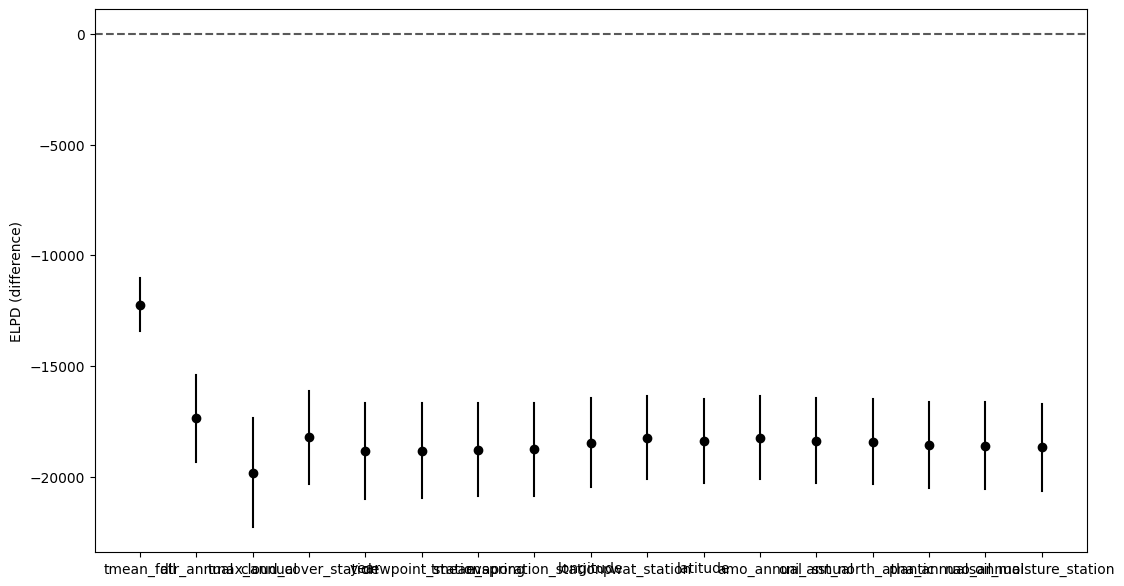

In [40]:
kpt.plot_compare(cmp_df)

/home/reu/.venv/lib/python3.14/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'chain' ('chain',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="model").assign_coords(model=list(data))
/home/reu/.venv/lib/python3.14/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'draw' ('draw',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="mode

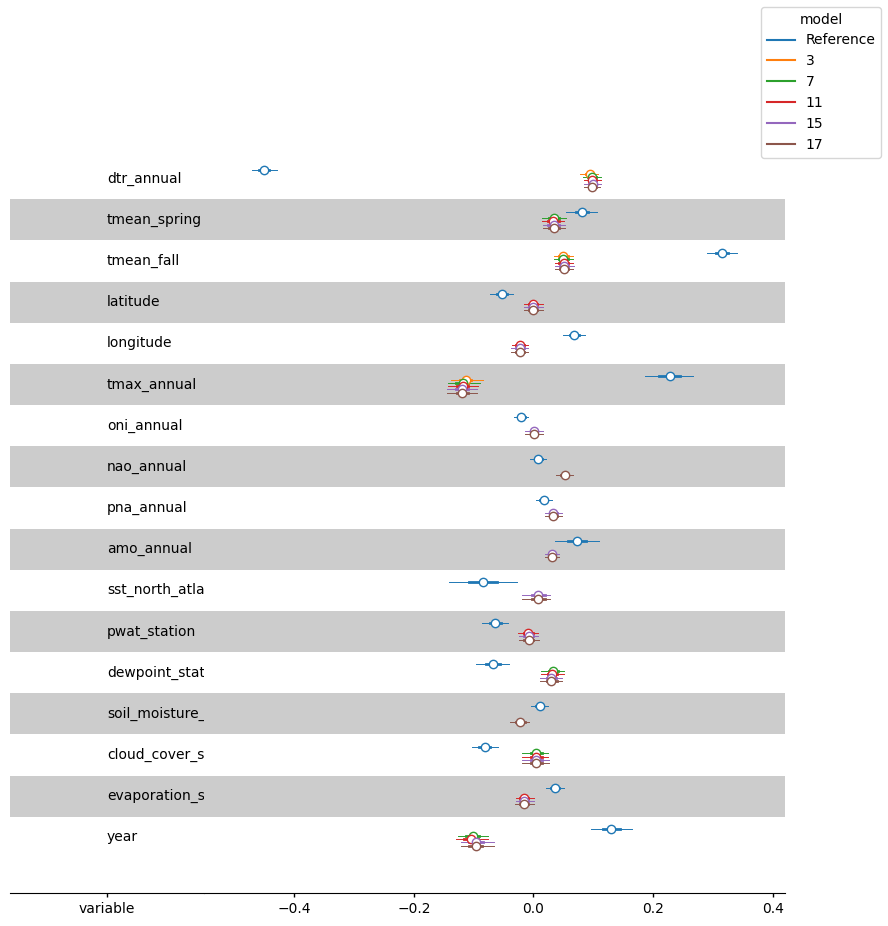

In [58]:
kpt.plot_forest(ppi, submodels = [3,7,11,15,17], include_reference = True, figure_kwargs= {"figsize": (10,10)})